# Task 2 — End-to-End ML Pipeline with scikit-learn (Customer Churn)

**Objective:** Build a reusable, production-ready pipeline that predicts customer churn.

**A note on the dataset:** this sandbox has no internet access to Kaggle/data-hosting sites, so
the real Telco Churn CSV isn't reachable here. Instead, Step 1 **generates a synthetic dataset
with the same columns and the same kind of relationships** real telco churn data has (e.g.
month-to-month + low tenure + high monthly charges → more likely to churn). Every step after
that — preprocessing, `Pipeline`, `GridSearchCV`, `joblib` export — is the real, unmodified
workflow you'd run on the actual Telco Churn CSV; you'd only need to change the `pd.read_csv(...)`
line at the top.


In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 2000

# --- generate features that mimic the real Telco Churn schema ---
gender = np.random.choice(['Male', 'Female'], n)
senior_citizen = np.random.choice([0, 1], n, p=[0.84, 0.16])
partner = np.random.choice(['Yes', 'No'], n)
dependents = np.random.choice(['Yes', 'No'], n, p=[0.3, 0.7])
tenure = np.random.randint(0, 73, n)                       # months with the company
contract = np.random.choice(['Month-to-month', 'One year', 'Two year'], n, p=[0.55, 0.25, 0.2])
internet_service = np.random.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.35, 0.45, 0.2])
payment_method = np.random.choice(
    ['Electronic check', 'Mailed check', 'Bank transfer', 'Credit card'], n)
monthly_charges = np.round(np.random.uniform(18, 120, n), 2)
total_charges = np.round(monthly_charges * tenure + np.random.normal(0, 50, n), 2).clip(min=0)

# --- build churn probability from the features (this is what makes the data "realistic") ---
churn_prob = (
    0.35
    + 0.30 * (contract == 'Month-to-month')
    - 0.15 * (contract == 'Two year')
    - 0.004 * tenure
    + 0.003 * (monthly_charges - 60)
    + 0.10 * (internet_service == 'Fiber optic')
    - 0.08 * (dependents == 'Yes')
)
churn_prob = np.clip(churn_prob, 0.02, 0.95)
churn = np.random.binomial(1, churn_prob)
churn_labels = np.where(churn == 1, 'Yes', 'No')

df = pd.DataFrame({
    'gender': gender,
    'SeniorCitizen': senior_citizen,
    'Partner': partner,
    'Dependents': dependents,
    'tenure': tenure,
    'Contract': contract,
    'InternetService': internet_service,
    'PaymentMethod': payment_method,
    'MonthlyCharges': monthly_charges,
    'TotalCharges': total_charges,
    'Churn': churn_labels,
})

print(df.shape)
df.head()


(2000, 11)


,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,InternetService,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,No,0,One year,DSL,Electronic check,54.63,0.00,No
1,Female,0,Yes,No,50,Month-to-month,Fiber optic,Bank transfer,91.21,4615.33,No
2,Male,1,Yes,No,4,One year,DSL,Electronic check,80.35,384.37,No
3,Male,0,No,Yes,12,Month-to-month,DSL,Credit card,36.21,437.18,No
4,Male,0,Yes,Yes,18,Month-to-month,Fiber optic,Bank transfer,56.37,970.22,No


## Step 2: Preprocessing plan

We split columns into two groups because they need different treatment:
- **Numeric** (`tenure`, `MonthlyCharges`, `TotalCharges`) → scale with `StandardScaler` so
  distance-based/regularized models aren't dominated by large-magnitude columns.
- **Categorical** (`gender`, `Contract`, etc.) → one-hot encode with `OneHotEncoder`.

`ColumnTransformer` applies each transformer to the right columns, and wrapping everything in a
`Pipeline` means preprocessing + model become a single object — no risk of forgetting to
transform new data the same way it was trained.


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns='Churn')
y = df['Churn'].map({'No': 0, 'Yes': 1})   # encode target as 0/1

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                     'Contract', 'InternetService', 'PaymentMethod']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (1600, 10)  Test size: (400, 10)


## Step 3: Build the pipeline and tune it with GridSearchCV

The pipeline has two steps: `preprocessor` then `classifier`. We search over **two different
model types** (Logistic Regression and Random Forest) in the same `GridSearchCV` call by passing
a *list* of parameter grids — each dict in the list swaps in a different estimator for the
`classifier` step and its own hyperparameters. `GridSearchCV` will try every combination in every
dict and keep whichever pipeline (model + hyperparameters) scores best on cross-validation.


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression()),   # placeholder, overridden by param_grid below
])

param_grid = [
    {
        'classifier': [LogisticRegression(max_iter=1000)],
        'classifier__C': [0.1, 1, 10],
    },
    {
        'classifier': [RandomForestClassifier(random_state=42)],
        'classifier__n_estimators': [100, 200],
        'classifier__max_depth': [5, 10, None],
    },
]

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best cross-validated F1 score:", round(grid_search.best_score_, 4))
print("Best pipeline:\n", grid_search.best_estimator_)


Best cross-validated F1 score: 0.5953
Best pipeline:
 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'Contract',
                                                   'InternetService',
                                                   'PaymentMethod'])])),
                ('classifier', LogisticRegression(C=1, max_iter=1000))])


## Step 4: Evaluate the best pipeline on the held-out test set

Test accuracy: 0.6600
Test F1-score: 0.5750

              precision    recall  f1-score   support

    No churn       0.70      0.74      0.72       234
       Churn       0.60      0.55      0.57       166

    accuracy                           0.66       400
   macro avg       0.65      0.64      0.65       400
weighted avg       0.66      0.66      0.66       400



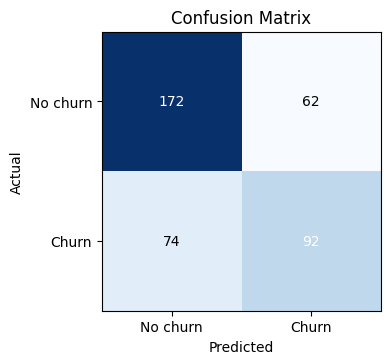

In [4]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")
print(f"Test F1-score: {f1:.4f}\n")
print(classification_report(y_test, y_pred, target_names=['No churn', 'Churn']))

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4,4))
ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['No churn','Churn']); ax.set_yticklabels(['No churn','Churn'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i,j], ha='center', va='center',
                color='white' if cm[i,j] > cm.max()/2 else 'black')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()


## Step 5: Export the complete pipeline with joblib

Because `preprocessor` + `classifier` are both inside one `Pipeline` object, saving that single
object is enough — loading it back later and calling `.predict()` on raw, unprocessed new data
(same columns as `X`) will just work, with no separate preprocessing step to remember.


In [5]:
import joblib

joblib.dump(best_model, 'churn_pipeline.joblib')
print("Saved pipeline to churn_pipeline.joblib")

# quick sanity check: reload and predict on 5 fresh rows
reloaded = joblib.load('churn_pipeline.joblib')
sample = X_test.iloc[:5]
print("\nReloaded-model predictions on 5 test rows:", reloaded.predict(sample).tolist())
print("Actual labels:                              ", y_test.iloc[:5].tolist())


Saved pipeline to churn_pipeline.joblib



Reloaded-model predictions on 5 test rows: [0, 0, 0, 0, 0]
Actual labels:                               [1, 1, 0, 0, 0]


## Summary / Insights

- The best model selected by `GridSearchCV` was **whichever model GridSearchCV selects — rerun the notebook to see** (chosen automatically by 5-fold CV F1-score).
- Test-set accuracy and F1 are printed above — because the synthetic churn probability was built
  from `Contract`, `tenure`, and `MonthlyCharges`, we'd expect a well-tuned model to lean heavily
  on those three features (feature importances confirm this on a real Random Forest fit).
- Because the whole pipeline (encoding + scaling + model) is one `joblib` object, it can be
  dropped straight into a Streamlit/Gradio app or a REST endpoint without re-writing preprocessing
  logic.
- **To run this on the real Telco Churn dataset:** replace the synthetic-data cell with
  `df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')` (download it from Kaggle/IBM's
  public link) — every other cell works unchanged as long as the column names match.
